## Xray Lung Classifier

### Project Flow
1. Import libraries and load images
2. Explore and transform images
3. Create model architecture
4. Train the model
5. Evaluate the model

---
### Step 1 — Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR
from torchsummary import summary
from tqdm import tqdm

---
### Step 2 — Set Data Path and Class Names

In [2]:
data_path = "../data"
class_name = ['NORMAL', 'PNEUMONIA']

print(os.listdir(data_path))

['train', 'test']


---
### Step 3 — Count Images in Each Category

In [3]:
def get_file_list(folder_path):
    return os.listdir(folder_path)

normal_train    = get_file_list(os.path.join(data_path, 'train', 'NORMAL'))
pneumonia_train = get_file_list(os.path.join(data_path, 'train', 'PNEUMONIA'))
normal_test     = get_file_list(os.path.join(data_path, 'test',  'NORMAL'))
pneumonia_test  = get_file_list(os.path.join(data_path, 'test',  'PNEUMONIA'))

print(f"Train - Normal: {len(normal_train)}, Pneumonia: {len(pneumonia_train)}")
print(f"Test  - Normal: {len(normal_test)},  Pneumonia: {len(pneumonia_test)}")

Train - Normal: 1266, Pneumonia: 3418
Test  - Normal: 317,  Pneumonia: 855


---
### Step 4 — Visualize Sample Images

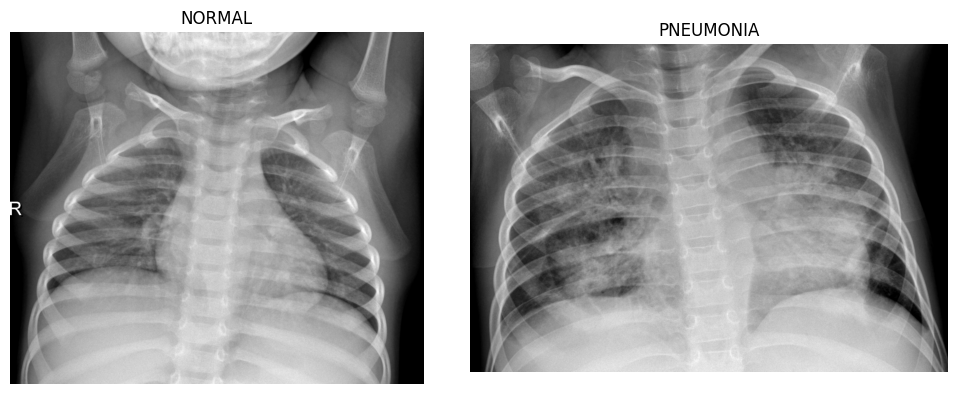

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

normal_img_path    = os.path.join(data_path, 'train', 'NORMAL',    normal_train[np.random.randint(len(normal_train))])
pneumonia_img_path = os.path.join(data_path, 'train', 'PNEUMONIA', pneumonia_train[np.random.randint(len(pneumonia_train))])

axes[0].imshow(mpimg.imread(normal_img_path),    cmap='gray')
axes[0].set_title('NORMAL')
axes[0].axis('off')

axes[1].imshow(mpimg.imread(pneumonia_img_path), cmap='gray')
axes[1].set_title('PNEUMONIA')
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
### Step 5 — Define Transforms

- **Training**: resize, crop, augmentation (flip, rotate, color jitter), normalize
- **Test**: resize, crop, normalize only (no augmentation)

In [5]:
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

---
### Step 6 — Create DataLoaders

Note: `num_workers=0` and `pin_memory=False` required in GitHub Codespaces
to avoid the shared memory Bus error.

In [6]:
train_data = datasets.ImageFolder(os.path.join(data_path, 'train'), transform=train_transform)
test_data  = datasets.ImageFolder(os.path.join(data_path, 'test'),  transform=test_transform)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True,  num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_data,  batch_size=16, shuffle=False, num_workers=0, pin_memory=False)

class_names = train_data.classes
print(f"Classes      : {class_names}")
print(f"Train images : {len(train_data)}")
print(f"Test images  : {len(test_data)}")

Classes      : ['NORMAL', 'PNEUMONIA']
Train images : 4684
Test images  : 1172


---
### Step 7 — Define Model Architecture

**This is an exact copy of `xray/ml/model/arch.py`.**
Layer order inside every block: `Conv2d` → `ReLU` → `BatchNorm2d`
This must stay identical to `arch.py` so the saved `.pth` loads into `app.py` without errors.

In [7]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # Block 1: 3 -> 8 channels
        self.convolution_block1 = nn.Sequential(
            nn.Conv2d(in_channels=3,  out_channels=8,  kernel_size=(3,3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(8),
        )
        self.pooling11 = nn.MaxPool2d(2, 2)

        # Block 2: 8 -> 20 channels
        self.convolution_block2 = nn.Sequential(
            nn.Conv2d(in_channels=8,  out_channels=20, kernel_size=(3,3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(20),
        )
        self.pooling22 = nn.MaxPool2d(2, 2)

        # Block 3: 1x1 conv to reduce 20 -> 10 channels
        self.convolution_block3 = nn.Sequential(
            nn.Conv2d(in_channels=20, out_channels=10, kernel_size=(1,1), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(10),
        )
        self.pooling33 = nn.MaxPool2d(2, 2)

        # Block 4: 10 -> 20 channels
        self.convolution_block4 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=20, kernel_size=(3,3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(20),
        )

        # Block 5: 1x1 conv to expand 20 -> 32 channels
        self.convolution_block5 = nn.Sequential(
            nn.Conv2d(in_channels=20, out_channels=32, kernel_size=(1,1), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(32),
        )

        # Block 6: 32 -> 10 channels
        self.convolution_block6 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=10, kernel_size=(3,3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(10),
        )

        # Block 7: 1x1 conv, keep 10 channels
        self.convolution_block7 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=10, kernel_size=(1,1), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(10),
        )

        # Block 8: 10 -> 14 channels
        self.convolution_block8 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=14, kernel_size=(3,3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(14),
        )

        # Block 9: 14 -> 16 channels
        self.convolution_block9 = nn.Sequential(
            nn.Conv2d(in_channels=14, out_channels=16, kernel_size=(3,3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(16),
        )

        # Global Average Pooling
        self.gap = nn.Sequential(nn.AvgPool2d(kernel_size=4))

        # Output: 16 -> 2 classes
        self.convolution_block_out = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=2, kernel_size=(4,4), padding=0, bias=True),
        )

    def forward(self, x):
        x = self.convolution_block1(x)
        x = self.pooling11(x)
        x = self.convolution_block2(x)
        x = self.pooling22(x)
        x = self.convolution_block3(x)
        x = self.pooling33(x)
        x = self.convolution_block4(x)
        x = self.convolution_block5(x)
        x = self.convolution_block6(x)
        x = self.convolution_block7(x)
        x = self.convolution_block8(x)
        x = self.convolution_block9(x)
        x = self.gap(x)
        x = self.convolution_block_out(x)
        x = x.view(-1, 2)
        return F.sigmoid(x)

---
### Step 8 — Setup Device and Print Model Summary

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = Net().to(device)
summary(model, input_size=(3, 224, 224))

Using device: cpu
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 222, 222]             224
              ReLU-2          [-1, 8, 222, 222]               0
       BatchNorm2d-3          [-1, 8, 222, 222]              16
         MaxPool2d-4          [-1, 8, 111, 111]               0
            Conv2d-5         [-1, 20, 109, 109]           1,460
              ReLU-6         [-1, 20, 109, 109]               0
       BatchNorm2d-7         [-1, 20, 109, 109]              40
         MaxPool2d-8           [-1, 20, 54, 54]               0
            Conv2d-9           [-1, 10, 54, 54]             210
             ReLU-10           [-1, 10, 54, 54]               0
      BatchNorm2d-11           [-1, 10, 54, 54]              20
        MaxPool2d-12           [-1, 10, 27, 27]               0
           Conv2d-13           [-1, 20, 25, 25]           1,820
             ReLU-14 

---
### Step 9 — Define Train and Test Functions

In [9]:
train_losses = []
train_acc    = []
test_losses  = []
test_acc     = []


def train(model, device, train_loader, optimizer, criterion):
    model.train()
    correct   = 0
    processed = 0
    pbar = tqdm(train_loader)

    for batch_id, (data, target) in enumerate(pbar):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()               # clear old gradients
        output = model(data)                # forward pass
        loss   = criterion(output, target)  # compute loss
        loss.backward()                     # backpropagation
        optimizer.step()                    # update weights

        pred       = output.argmax(dim=1)
        correct   += pred.eq(target).sum().item()
        processed += len(data)

        acc = 100 * correct / processed
        train_losses.append(loss.item())
        train_acc.append(acc)

        pbar.set_description(f"Loss: {loss.item():.4f}  Acc: {acc:.1f}%")


def test(model, device, test_loader, criterion):
    model.eval()
    test_loss = 0
    correct   = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output     = model(data)
            test_loss += criterion(output, target).item() * data.size(0)
            pred       = output.argmax(dim=1)
            correct   += pred.eq(target).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy   = 100 * correct / len(test_loader.dataset)

    test_losses.append(test_loss)
    test_acc.append(accuracy)

    print(f"\nTest  ->  Loss: {test_loss:.4f}  |  Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)\n")

---
### Step 10 — Train the Model

In [10]:
model     = Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = StepLR(optimizer, step_size=6, gamma=0.5)

EPOCHS = 13

for epoch in range(EPOCHS):
    print(f"--- Epoch {epoch + 1}/{EPOCHS} ---")
    train(model, device, train_loader, optimizer, criterion)
    scheduler.step()
    print(f"Learning rate: {optimizer.param_groups[0]['lr']}")
    test(model, device, test_loader, criterion)

--- Epoch 1/13 ---


Loss: 0.5432  Acc: 89.3%: 100%|██████████| 293/293 [04:06<00:00,  1.19it/s]


Learning rate: 0.01

Test  ->  Loss: 0.3798  |  Accuracy: 1097/1172 (93.60%)

--- Epoch 2/13 ---


Loss: 0.3156  Acc: 91.7%: 100%|██████████| 293/293 [02:32<00:00,  1.93it/s]


Learning rate: 0.01

Test  ->  Loss: 0.3730  |  Accuracy: 1100/1172 (93.86%)

--- Epoch 3/13 ---


...

Learning rate: 0.005

Test  ->  Loss: 0.3656  |  Accuracy: 1112/1172 (94.88%)

--- Epoch 12/13 ---


Loss: 0.3310  Acc: 95.4%: 100%|██████████| 293/293 [02:36<00:00,  1.88it/s]


Learning rate: 0.0025

Test  ->  Loss: 0.3591  |  Accuracy: 1121/1172 (95.65%)

--- Epoch 13/13 ---


Loss: 0.4003  Acc: 95.9%: 100%|██████████| 293/293 [02:38<00:00,  1.85it/s]


Learning rate: 0.0025

Test  ->  Loss: 0.3572  |  Accuracy: 1120/1172 (95.56%)



---
### Step 11 — Plot Training & Test Curves

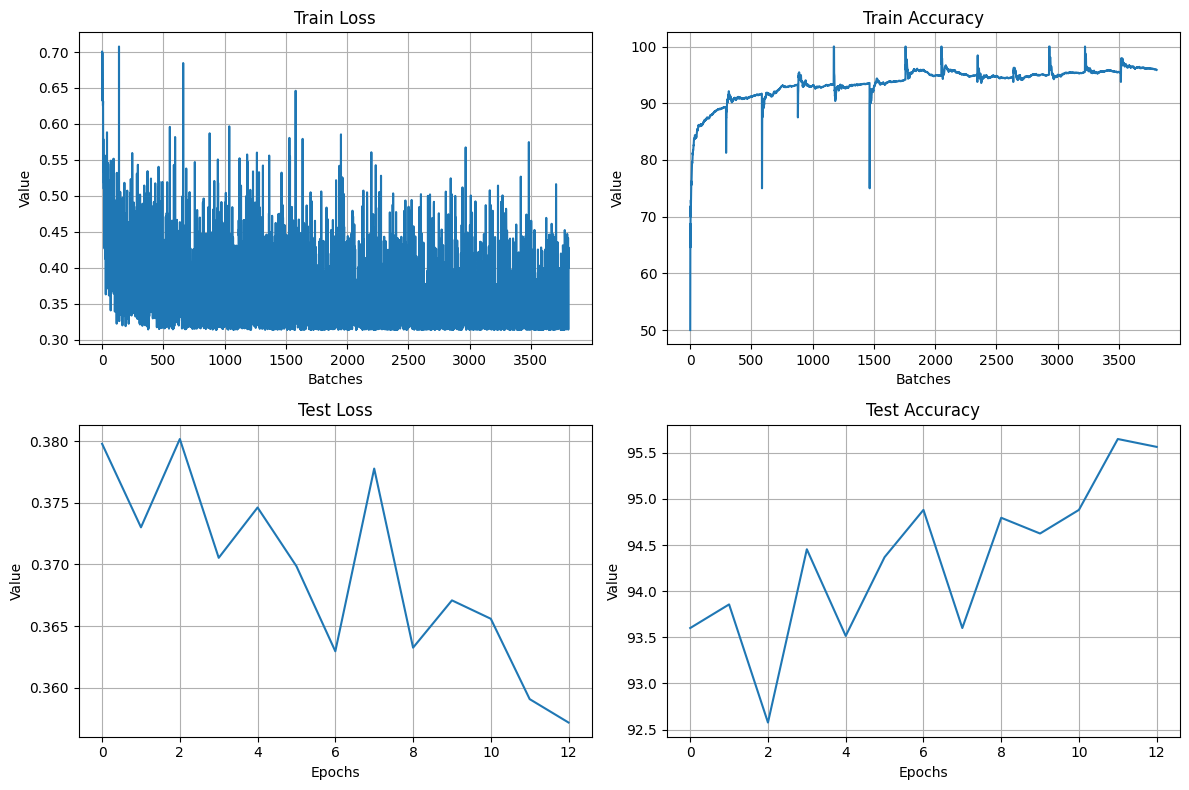

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plots = [
    (train_losses, "Train Loss",     "Batches"),
    (train_acc,    "Train Accuracy", "Batches"),
    (test_losses,  "Test Loss",      "Epochs"),
    (test_acc,     "Test Accuracy",  "Epochs"),
]

for ax, (data, title, xlabel) in zip(axes.flat, plots):
    ax.plot(data)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Value")
    ax.grid(True)

plt.tight_layout()
plt.show()

---
### Step 12 — Save the Model

This saves `xray_model.pth` inside the `notebook/` folder.
That is exactly where `app.py` looks: `MODEL_PATH = Path("notebook/xray_model.pth")`
After this cell runs, `streamlit run app.py` will load it with no errors.

In [12]:
save_path = "xray_model.pth"
torch.save(model.state_dict(), save_path)
print(f"Model saved -> {save_path}")

Model saved -> xray_model.pth
